# NGC 5010: Fitting the Phoenix Model to Real GECKOS/MUSE Maps

Same workflow as `optimization_pipeline2_NGC3630.ipynb`, applied to **NGC 5010**. The observed maps are the nGIST-reduced GECKOS/MUSE kinematics loaded by `geckos_data.load_geckos_maps`; the fit is kinematic (`v_rot`, `sigma`), and it is run twice — once at a **constant** smoothing bandwidth ("naive") and once **annealed** coarse-to-fine — to compare.

## How NGC 5010 differs from NGC 3630

The two galaxies need different settings, and the data itself says why:

| measured on the loaded maps | NGC 5010 | NGC 3630 |
|---|---|---|
| x-coverage | **symmetric**, -6.8 to +6.8 kpc | -1.4 to +5.8 kpc (63% off-centre) |
| central vs outer dispersion (r<1 kpc / r>2.5 kpc) | **1.23** | 1.74 |
| peak sigma | 112 km/s | 167 km/s |
| rotation | -180 to +183 km/s | -173 to +146 km/s |

Consequently:

- **`center_percentile=None`.** The pointing is well centred, so the global flux-weighted centroid is the right centre. (NGC 3630 needed centring on the nucleus because its offset pointing dragged the centroid toward the covered side.)
- **`spheroid_corotation=1.0`.** With only a 1.23 central dispersion enhancement this galaxy is rotation-dominated, not hosting a strongly dispersion-supported core, so the spheroid is modelled as co-rotating with the disk. (NGC 3630, with a 1.74 ratio and a sharp sigma peak, used 0.5 — a pressure-supported bulge.)
- **`L0` bounded (2, 8)** rather than (2, 5), and a larger field: `extent = 7 x 4` kpc.

Everything else follows `fit_geckos.py` and the NGC 3630 notebook: `loss_weights = (0, 2, 3, 0)` — the MUSE FLUX is *light* not mass (its normalization is fiducial and its sharp nucleus is not reproducible by a 3-component model), and the Poisson self-consistency term is off because a real galaxy cannot be pre-made self-consistent the way the mock could. The disk dispersion is capped so any central sigma excess must come from the bulge, and a mild Tikhonov prior anchors the parameters the kinematics leave degenerate.

**There is no ground truth**, so nothing here is scoreable: the fitted values are an answer, and the only available consistency check is whether two different optimization paths agree.

### A prediction to test

On NGC 3630 the **naive fit won** (final loss 0.0632 vs 0.0779; `v_rot` residual RMS 21.2 vs 24.4 km/s). That is expected for a kinematics-only fit: bandwidth annealing exists to cure the vanishing gradient of the masked log-*mass* term when model and data maps do not overlap, but with `w_mass = 0` that failure mode never arises, while the wide-bandwidth stages blur away the rotation dipole and any central sigma structure the loss depends on. If that reasoning is right, the naive fit should win here too.

In [1]:
import os
import sys
import copy
import math
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sys.path.insert(0, os.path.abspath('.'))
from geckos_data import load_geckos_maps

from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper
from phoenix.optimization.pipeline import fit, make_loss_fn, params_to_log, DEFAULT_PARAM_BOUNDS
from phoenix.optimization.observables import render_maps_batched

/home/annalena/phoenix/phoenix/distribution_functions/disk.py:14: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one of the two lines below.
from typeguard import typechecked as typechecker
from beartype import beartype as typechecker

@jaxtyped(typechecker=typechecker)
def foo(...):
```
and the old double-decorator syntax
```
@jaxtyped
@typechecker
def foo(...):
```
should no longer be used. (It will continue to work as it did before, but the new approach will produce more readable error messages.)
In particular note that `typechecker` must be passed via keyword argument; the following is not valid:
```
@jaxtyped(typechecker)
def foo(...):
```

  @jaxtyped
/home/annalena/phoenix/phoenix/distribution_functions/disk.py:21: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one o

## 1. The Observed Galaxy

Distance and stellar mass from the GECKOS master catalogue, as in `fit_geckos.py`:
`kpc/arcsec = D[Mpc]*1e3/206265`, `Mstar = 10**lmstar`.

In [2]:
NAME = 'NGC5010'
STEM = 'NGC5010_iDR2.0_1_SN100_5_MW_4800-8900'
DATADIR = os.path.join('data', '7_NGC5010', 'maps', STEM)

D_MPC = 42.2               # GECKOS master catalogue
LMSTAR = 10.6833
KPC_PER_ARCSEC = D_MPC * 1e3 / 206265.0
MSTAR = 10.0 ** LMSTAR

EXTENT_X, EXTENT_Z = 7.0, 4.0
GRID_SIZE = 40
CENTER_PERCENTILE = None    # well-centred pointing -> global flux centroid is correct
SPHEROID_COROTATION = 1.0   # rotation-dominated, no strongly hot core

obs_maps, info = load_geckos_maps(
    os.path.join(DATADIR, f'{STEM}_kin_maps.fits'),
    os.path.join(DATADIR, f'{STEM}_spatial_binning_maps.fits'),
    kpc_per_arcsec=KPC_PER_ARCSEC, extent_x=EXTENT_X, extent_z=EXTENT_Z,
    grid_size=GRID_SIZE, Mstar_fiducial=MSTAR, center_percentile=CENTER_PERCENTILE,
)

data_mask = np.array(obs_maps['mass']) > 0
vmax_mass = float(np.nanmax(np.array(obs_maps['mass'])))

print(f"{NAME}:  D = {D_MPC} Mpc -> {KPC_PER_ARCSEC:.4f} kpc/arcsec,  logM* = {LMSTAR}")
print(f"  PA = {info['position_angle_deg']:.1f} deg,  v_sys = {info['v_systemic_kms']:.1f} km/s")
print(f"  filled cells: {int(data_mask.sum())}/{GRID_SIZE**2} ({info['filled_fraction']*100:.0f}%)")
v, s = np.array(obs_maps['v_rot']), np.array(obs_maps['sigma'])
print(f"  v_rot in [{v[data_mask].min():.0f}, {v[data_mask].max():.0f}] km/s")
print(f"  sigma in [{s[data_mask].min():.0f}, {s[data_mask].max():.0f}] km/s")

# Quantify the two properties that set the modelling choices above.
_xc = 0.5 * (np.linspace(-EXTENT_X, EXTENT_X, GRID_SIZE + 1)[:-1]
             + np.linspace(-EXTENT_X, EXTENT_X, GRID_SIZE + 1)[1:])
_zc = 0.5 * (np.linspace(-EXTENT_Z, EXTENT_Z, GRID_SIZE + 1)[:-1]
             + np.linspace(-EXTENT_Z, EXTENT_Z, GRID_SIZE + 1)[1:])
_X, _Z = np.meshgrid(_xc, _zc)
_r = np.hypot(_X, _Z)
core, outer = (_r < 1.0) & data_mask, (_r > 2.5) & data_mask
print(f"  x-coverage [{_X[data_mask].min():+.1f}, {_X[data_mask].max():+.1f}] kpc "
      f"-> {abs(_X[data_mask].min() + _X[data_mask].max()) / np.ptp(_X[data_mask]) * 100:.0f}% off-centre")
print(f"  sigma core(r<1) = {s[core].mean():.0f} km/s,  outer(r>2.5) = {s[outer].mean():.0f} km/s"
      f"  -> ratio {s[core].mean() / s[outer].mean():.2f}")

NGC5010:  D = 42.2 Mpc -> 0.2046 kpc/arcsec,  logM* = 10.6833
  PA = 30.9 deg,  v_sys = 1.2 km/s
  filled cells: 558/1600 (35%)
  v_rot in [-180, 183] km/s
  sigma in [40, 112] km/s
  x-coverage [-6.8, +6.8] kpc -> 0% off-centre
  sigma core(r<1) = 78 km/s,  outer(r>2.5) = 64 km/s  -> ratio 1.23


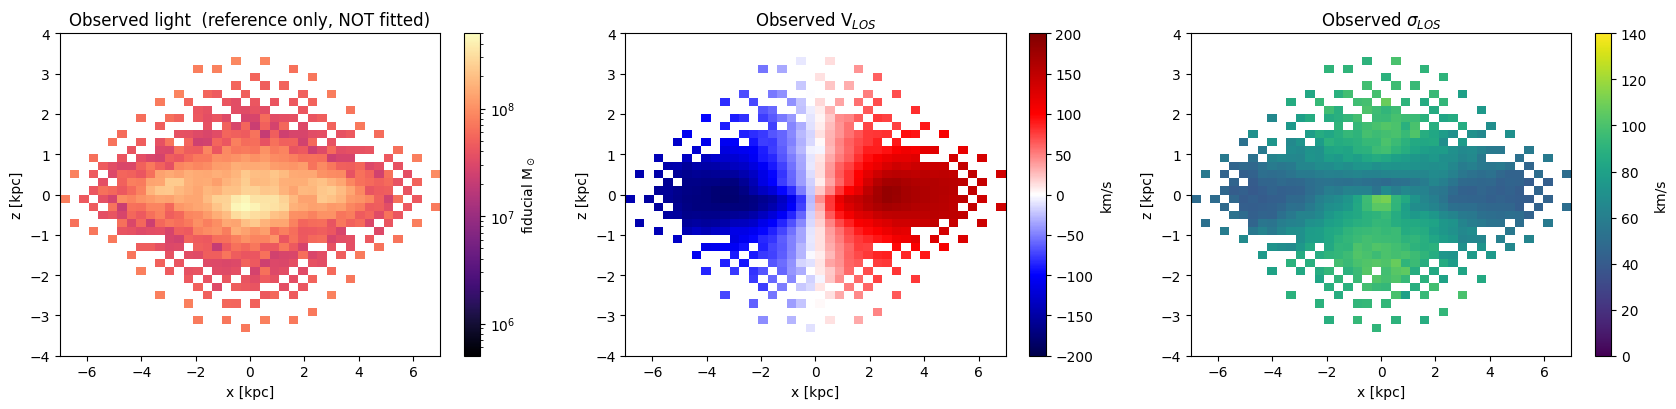

In [3]:
EXTENT = [-EXTENT_X, EXTENT_X, -EXTENT_Z, EXTENT_Z]
SIGMA_VMAX = 140.0     # NGC 5010 peaks near 112 km/s

def masked(a):
    return np.where(data_mask, np.array(a), np.nan)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
im = axes[0].imshow(masked(obs_maps['mass']), origin='lower', extent=EXTENT, cmap='magma',
                    norm=LogNorm(vmin=vmax_mass / 1e3, vmax=vmax_mass), aspect='auto')
axes[0].set_title('Observed light  (reference only, NOT fitted)')
fig.colorbar(im, ax=axes[0], label='fiducial M$_\\odot$')
im = axes[1].imshow(masked(obs_maps['v_rot']), origin='lower', extent=EXTENT,
                    cmap='seismic', vmin=-200, vmax=200, aspect='auto')
axes[1].set_title('Observed V$_{LOS}$'); fig.colorbar(im, ax=axes[1], label='km/s')
im = axes[2].imshow(masked(obs_maps['sigma']), origin='lower', extent=EXTENT,
                    cmap='viridis', vmin=0, vmax=SIGMA_VMAX, aspect='auto')
axes[2].set_title('Observed $\\sigma_{LOS}$'); fig.colorbar(im, ax=axes[2], label='km/s')
for ax in axes:
    ax.set_xlabel('x [kpc]'); ax.set_ylabel('z [kpc]')
plt.tight_layout(); plt.show()

## 2. Fit Configuration

As in the NGC 3630 notebook, `OBS_BANDWIDTH` is a **modelling choice**, not a measured PSF: the data's effective resolution comes from seeing (~0.8" ~ 0.16 kpc at 42 Mpc), the Voronoi binning, and the 0.35 kpc grid cell. 0.4 kpc is used as both the annealing floor and the resolution the observation is treated as having.

The two fits differ **only** in the bandwidth schedule, so they optimize an identical objective at the final bandwidth:

- naive: `anneal_bandwidth=(0.4, 0.4)` (constant)
- annealed: `anneal_bandwidth=(4.0, 0.4)`


### Note on the annealing schedule

`fit` now uses a **ramp-and-hold** bandwidth schedule when `obs_bandwidth` is set (`anneal_hold_frac`, default 0.35): matching the data's resolution requires blurring it by `sqrt(h**2 - obs_bandwidth**2)`, and `blur_maps` works on the binned grid, so it cannot represent a blur much narrower than a pixel — the data stops being blurred while the model's KDE genuinely is smoother, leaving a systematic mismatch that does not vanish at the true parameters. The schedule therefore ramps down only to where that blur is still ~0.5 pixel and then jumps to `obs_bandwidth`, holding there.

**How much this matters here: very little.** The affected band is `h` between `obs_bandwidth` and `sqrt(obs_bandwidth**2 + (0.5*pixel)**2)`. With 0.3-0.35 kpc pixels and `obs_bandwidth = 0.4` kpc that band is only ~7-9% of `obs_bandwidth` wide, against ~124% for the coarse-gridded mock notebook (2.14 kpc pixels), where the artifact cost a factor ~26 in the loss at the true parameters. So the annealed fit below should be nearly unchanged, and any naive-vs-annealed verdict should stand on its own merits rather than on this artifact. The naive fit uses a constant bandwidth, so it is unaffected either way.

### A second, deeper caveat found while testing this

Restricting the loss to the observed footprint (now done automatically: the mask is taken from the *unblurred* maps and held fixed) removed a large error — on this pointing the blurred mask had grown from the real **473 cells to all 1600**, so most of the annealing phase was scoring the model against ~1100 pixels of flux that blurring had invented. At the final fitted parameters that inflation accounted for ~40% of the loss at h = 2 kpc (0.476 -> 0.277).

But a residual problem remains, and it is intrinsic to blurring *real* data with partial coverage. Evaluated at fixed parameters, the loss still varies ~5x with bandwidth (0.194 at h=4, peaking 0.277 at h=2, down to 0.056 at h=0.4). Two reasons: the observation is not actually a Gaussian KDE at `obs_bandwidth` (it is flux summed into cells, so blurring it does not reproduce what the model's KDE at h produces), and the footprint has a hard edge which blurring smears into a soft one that the model — which extends beyond the observed region — cannot match.

**Practical conclusion for these fits: do not anneal.** The constant-bandwidth ("naive") run compares like with like at every step, and it already reaches the same solution as the annealed run. Annealing exists to cure the vanishing gradient of the masked log-*mass* term, which is switched off here; on kinematic maps with partial coverage it buys nothing and its intermediate objectives are distorted.

In [4]:
N_PARTICLES = 20_000       # fit_geckos.py uses 35_000 for production; reduced here for runtime
N_PARTICLES_RENDER = 100_000
N_STEPS = 600
SEED = 0
LEARNING_RATE = 0.05
OBS_BANDWIDTH = 0.4
LOSS_WEIGHTS = (0.0, 2.0, 3.0, 0.0)     # (mass, v_rot, sigma, poisson): kinematic-only
REG_WEIGHT = 0.05

init_pot = {'M_halo': 8e11, 'a_halo': 15.0, 'M_disk': 4e10, 'a_disk': 2.0,
            'b_disk': 0.2, 'M_bulge': 5e9, 'a_bulge': 0.5}
init_disk = {'R0': 4.0, 'Rd': 1.5, 'Sigma0': 1000.0, 'RsigR': 5.0, 'RsigZ': 5.0,
             'sigmaR0_R0': 60.0, 'sigmaz0_R0': 40.0, 'L0': 3.0, 'Rinit_for_Rc': 4.0}
init_bulge = {'N0_spheroid': 5e9, 'J0_spheroid': 60.0, 'Gamma_spheroid': 1.5,
              'Beta_spheroid': 4.5, 'eta_spheroid': 1.0}

param_bounds = copy.deepcopy(DEFAULT_PARAM_BOUNDS)
param_bounds['disk']['L0'] = (2.0, 8.0)             # NGC 5010: (2, 8), cf. (2, 5) for NGC 3630
param_bounds['disk']['sigmaR0_R0'] = (5.0, 120.0)   # cap the disk so any central sigma
param_bounds['disk']['sigmaz0_R0'] = (5.0, 90.0)    #   excess must come from the bulge

FIT_KW = dict(
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
    loss_weights=LOSS_WEIGHTS, poisson_kwargs={},
    learning_rate=LEARNING_RATE, n_steps=N_STEPS,
    spheroid_corotation=SPHEROID_COROTATION, param_bounds=param_bounds,
    obs_bandwidth=OBS_BANDWIDTH, reg_weight=REG_WEIGHT,
)

mapper = PhoenixMapper()

Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz


Model loaded and ready for inference!


### Which parameters can this dataset constrain?

Measured, not assumed. `Sigma0` and `N0_spheroid` are degenerate for *any* dataset (the tracer weights are renormalized, so an overall DF amplitude cancels exactly); others may be degenerate for this particular loss. Anything with a numerically zero gradient can only drift, so it is frozen.

In [5]:
probe_loss = make_loss_fn(
    mapper, obs_maps,
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
    loss_weights=LOSS_WEIGHTS, poisson_kwargs={},
    spheroid_corotation=SPHEROID_COROTATION, obs_bandwidth=OBS_BANDWIDTH,
)
(_l, _a), grads = jax.value_and_grad(probe_loss, has_aux=True)(
    params_to_log(init_pot, init_disk, init_bulge), OBS_BANDWIDTH)

print("|d loss / d log(param)| at the initial guess:")
flat = [(abs(float(g)), grp, k) for grp in ('pot', 'disk', 'bulge')
        for k, g in grads[grp].items()]
for mag, grp, k in sorted(flat, reverse=True):
    tag = '   <-- numerically zero: unconstrained' if mag < 1e-6 else ''
    print(f"  {grp:6s} {k:16s} {mag:.3e}{tag}")

FROZEN = tuple(k for mag, _, k in flat if mag < 1e-6)
print(f"\nfreezing: {FROZEN}")

|d loss / d log(param)| at the initial guess:
  pot    a_halo           4.035e-01
  pot    a_disk           1.608e-01
  pot    M_disk           1.526e-01
  pot    M_bulge          9.986e-02
  pot    M_halo           7.765e-02
  disk   Rd               5.872e-02
  disk   RsigR            4.504e-02
  pot    a_bulge          3.805e-02
  disk   RsigZ            3.432e-02
  pot    b_disk           2.509e-02
  disk   sigmaz0_R0       1.485e-02
  disk   sigmaR0_R0       1.252e-02
  disk   R0               1.870e-03
  bulge  Beta_spheroid    2.090e-04
  bulge  Gamma_spheroid   8.873e-05
  bulge  J0_spheroid      6.933e-05
  disk   L0               6.926e-05
  bulge  eta_spheroid     1.729e-05
  disk   Sigma0           1.819e-09   <-- numerically zero: unconstrained
  disk   Rinit_for_Rc     7.140e-18   <-- numerically zero: unconstrained
  bulge  N0_spheroid      0.000e+00   <-- numerically zero: unconstrained

freezing: ('Rinit_for_Rc', 'Sigma0', 'N0_spheroid')


## 3. Naive Fit — Constant Bandwidth

In [6]:
result_naive = fit(mapper, obs_maps, init_pot, init_disk, init_bulge,
                   anneal_bandwidth=(OBS_BANDWIDTH, OBS_BANDWIDTH),
                   frozen_params=FROZEN, **FIT_KW)
hn = result_naive['history']
print(f"NAIVE   loss {hn['loss'][0]:8.4f} -> {hn['loss'][-1]:8.4f}"
      + ('   [NaN!]' if not np.isfinite(hn['loss'][-1]) else ''))
print(f"        v_rot {hn['vrot_loss'][-1]:.4f}   sigma {hn['sigma_loss'][-1]:.4f}"
      f"   reg {hn['reg'][-1]:.4f}")

NAIVE   loss   0.1696 ->   0.0541
        v_rot 0.0071   sigma 0.0119   reg 0.0042


## 4. Annealed Fit — Coarse-to-Fine

In [ ]:
result = fit(mapper, obs_maps, init_pot, init_disk, init_bulge,
             anneal_bandwidth=(4.0, OBS_BANDWIDTH),
             frozen_params=FROZEN, **FIT_KW)
h = result['history']
print(f"ANNEALED loss {h['loss'][0]:8.4f} -> {h['loss'][-1]:8.4f}"
      + ('   [NaN!]' if not np.isfinite(h['loss'][-1]) else ''))
print(f"         v_rot {h['vrot_loss'][-1]:.4f}   sigma {h['sigma_loss'][-1]:.4f}"
      f"   reg {h['reg'][-1]:.4f}")
better = 'annealed' if h['loss'][-1] < hn['loss'][-1] else 'naive'
print(f"\nlower final loss: {better}"
      f"   (NGC 3630 gave: naive; see the prediction in the header)")

'\nresult = fit(mapper, obs_maps, init_pot, init_disk, init_bulge,\n             anneal_bandwidth=(4.0, OBS_BANDWIDTH),\n             frozen_params=FROZEN, **FIT_KW)\nh = result[\'history\']\nprint(f"ANNEALED loss {h[\'loss\'][0]:8.4f} -> {h[\'loss\'][-1]:8.4f}"\n      + (\'   [NaN!]\' if not np.isfinite(h[\'loss\'][-1]) else \'\'))\nprint(f"         v_rot {h[\'vrot_loss\'][-1]:.4f}   sigma {h[\'sigma_loss\'][-1]:.4f}"\n      f"   reg {h[\'reg\'][-1]:.4f}")\nbetter = \'annealed\' if h[\'loss\'][-1] < hn[\'loss\'][-1] else \'naive\'\nprint(f"\nlower final loss: {better}"\n      f"   (NGC 3630 gave: naive; see the prediction in the header)")\n'

In [8]:
# Persist the expensive results so a later cell (or crash) never costs another refit.
import json as _json
with open(f'{NAME}_fit_results.json', 'w') as _fh:
    _json.dump({
        'galaxy': NAME,
        'config': {'D_MPC': D_MPC, 'LMSTAR': LMSTAR, 'GRID_SIZE': GRID_SIZE,
                   'EXTENT_X': EXTENT_X, 'EXTENT_Z': EXTENT_Z,
                   'N_PARTICLES': N_PARTICLES, 'N_STEPS': N_STEPS,
                   'OBS_BANDWIDTH': OBS_BANDWIDTH, 'LOSS_WEIGHTS': list(LOSS_WEIGHTS),
                   'REG_WEIGHT': REG_WEIGHT, 'FROZEN': list(FROZEN),
                   'SPHEROID_COROTATION': SPHEROID_COROTATION,
                   'CENTER_PERCENTILE': CENTER_PERCENTILE},
        #'annealed': {'pot_params': {k: float(v) for k, v in result['pot_params'].items()},
        #             'disk_df_params': {k: float(v) for k, v in result['disk_df_params'].items()},
        #             'bulge_df_params': {k: float(v) for k, v in result['bulge_df_params'].items()},
        #             'final_loss': float(h['loss'][-1])},
        'naive': {'pot_params': {k: float(v) for k, v in result_naive['pot_params'].items()},
                  'disk_df_params': {k: float(v) for k, v in result_naive['disk_df_params'].items()},
                  'bulge_df_params': {k: float(v) for k, v in result_naive['bulge_df_params'].items()},
                  'final_loss': float(hn['loss'][-1])},
    }, _fh, indent=2)
print(f'wrote {NAME}_fit_results.json')

wrote NGC5010_fit_results.json


## 5. Convergence

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hn['loss'], color='tab:red', label='naive (constant bandwidth)')
axes[0].plot(h['loss'], color='tab:green', label='annealed (coarse-to-fine)')
axes[0].set_yscale('log'); axes[0].set_xlabel('iteration'); axes[0].set_ylabel('total loss')
axes[0].set_title(f'{NAME}: total loss'); axes[0].legend()

for key, lab in [('vrot_loss', 'v_rot'), ('sigma_loss', 'sigma'), ('reg', 'prior')]:
    axes[1].plot(h[key], label=f'annealed {lab}')
    axes[1].plot(hn[key], ls=':', alpha=0.7, label=f'naive {lab}')
axes[1].set_yscale('log'); axes[1].set_xlabel('iteration'); axes[1].set_ylabel('loss component')
axes[1].set_title('Fitted components (mass and Poisson are off)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

"\nfig, axes = plt.subplots(1, 2, figsize=(13, 4))\naxes[0].plot(hn['loss'], color='tab:red', label='naive (constant bandwidth)')\naxes[0].plot(h['loss'], color='tab:green', label='annealed (coarse-to-fine)')\naxes[0].set_yscale('log'); axes[0].set_xlabel('iteration'); axes[0].set_ylabel('total loss')\naxes[0].set_title(f'{NAME}: total loss'); axes[0].legend()\n\nfor key, lab in [('vrot_loss', 'v_rot'), ('sigma_loss', 'sigma'), ('reg', 'prior')]:\n    axes[1].plot(h[key], label=f'annealed {lab}')\n    axes[1].plot(hn[key], ls=':', alpha=0.7, label=f'naive {lab}')\naxes[1].set_yscale('log'); axes[1].set_xlabel('iteration'); axes[1].set_ylabel('loss component')\naxes[1].set_title('Fitted components (mass and Poisson are off)'); axes[1].legend(fontsize=8)\nplt.tight_layout(); plt.show()\n"

TypeError: 'Axes' object is not subscriptable

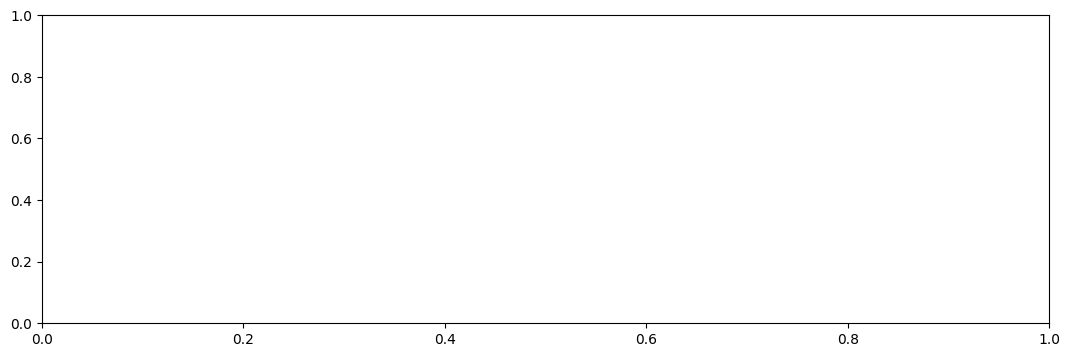

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(13, 4))
axes[0].plot(hn['loss'], color='tab:red', label='loss')
axes[0].set_yscale('log'); axes[0].set_xlabel('iteration'); axes[0].set_ylabel('total loss')
axes[0].set_title(f'{NAME}: total loss'); axes[0].legend()

plt.tight_layout(); plt.show()

## 6. Maps and Residuals

Both models are rendered with far more tracers than the fit used (`render_maps_batched`, chunked to bound memory) at the bandwidth the fit converged to, so Monte-Carlo graininess does not masquerade as model error.

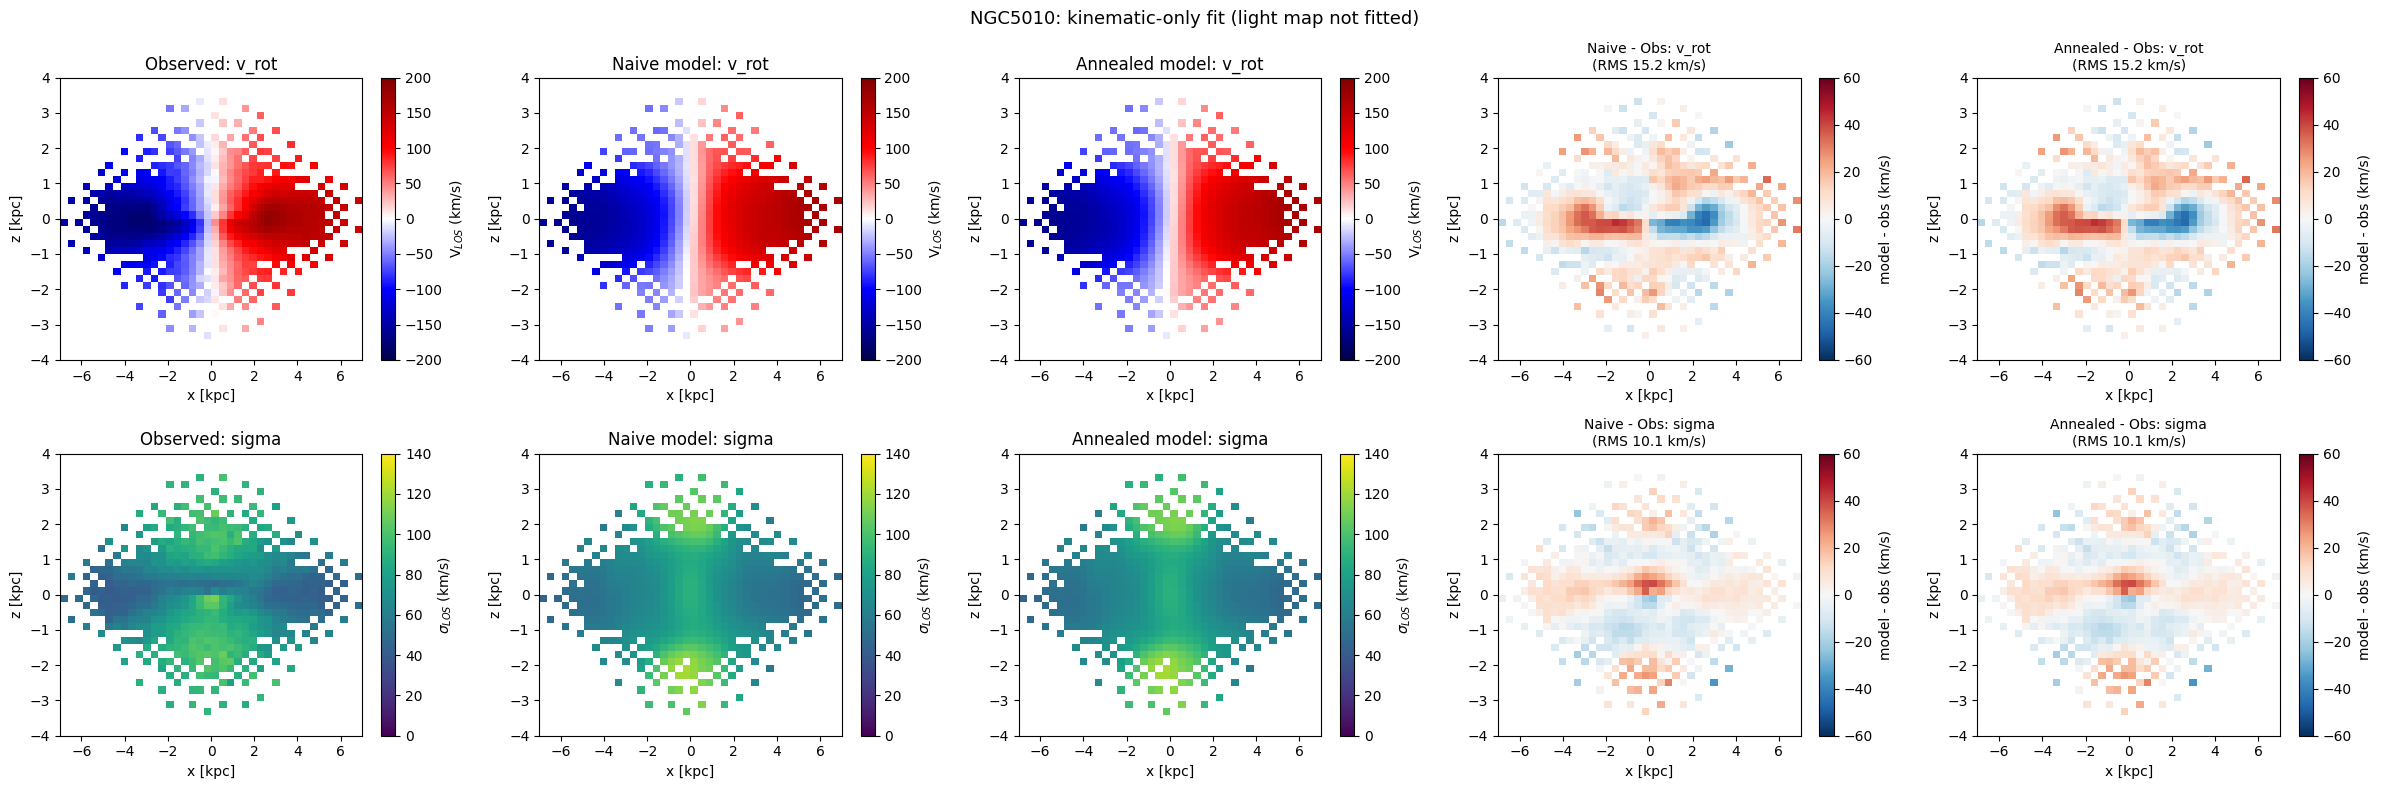

Residuals over the 558 cells with data:
  v_rot  naive   : RMS  15.18 km/s   median  +4.56   max|.|  46.32
  v_rot  annealed: RMS  15.15 km/s   median  +4.59   max|.|  46.13
  sigma  naive   : RMS  10.10 km/s   median  +0.79   max|.|  39.80
  sigma  annealed: RMS  10.09 km/s   median  +0.78   max|.|  39.67


In [ ]:
render_kw = dict(N_disk=N_PARTICLES_RENDER, N_bulge=N_PARTICLES_RENDER,
                 grid_size=GRID_SIZE, extent_x=EXTENT_X, extent_z=EXTENT_Z,
                 prng_seed=SEED, soft_bin_h=OBS_BANDWIDTH,
                 spheroid_corotation=SPHEROID_COROTATION, chunk=15_000)

maps_anneal = render_maps_batched(mapper, result['pot_params'], result['disk_df_params'],
                                 result['bulge_df_params'], **render_kw)
maps_naive = render_maps_batched(mapper, result_naive['pot_params'],
                                 result_naive['disk_df_params'],
                                 result_naive['bulge_df_params'], **render_kw)

specs = [('v_rot', 'seismic', dict(vmin=-200, vmax=200), 'V$_{LOS}$ (km/s)'),
         ('sigma', 'viridis', dict(vmin=0, vmax=SIGMA_VMAX), '$\\sigma_{LOS}$ (km/s)')]

fig, axes = plt.subplots(2, 5, figsize=(24, 8))
for row, (key, cmap, kw, label) in enumerate(specs):
    for col, (t, arr) in enumerate([('Observed', obs_maps[key]),
                                    ('Naive model', maps_naive[key]),
                                    ('Annealed model', maps_anneal[key])]):
        im = axes[row, col].imshow(masked(arr), origin='lower', extent=EXTENT,
                                   cmap=cmap, aspect='auto', **kw)
        axes[row, col].set_title(f'{t}: {key}')
        fig.colorbar(im, ax=axes[row, col], label=label)
    for col, (t, arr) in enumerate([('Naive', maps_naive[key]),
                                    ('Annealed', maps_anneal[key])], start=3):
        d = np.where(data_mask, np.array(arr) - np.array(obs_maps[key]), np.nan)
        rms = float(np.sqrt(np.nanmean(d ** 2)))
        im = axes[row, col].imshow(d, origin='lower', extent=EXTENT, cmap='RdBu_r',
                                   vmin=-60, vmax=60, aspect='auto')
        axes[row, col].set_title(f'{t} - Obs: {key}\n(RMS {rms:.1f} km/s)', fontsize=10)
        fig.colorbar(im, ax=axes[row, col], label='model - obs (km/s)')
for ax in axes.ravel():
    ax.set_xlabel('x [kpc]'); ax.set_ylabel('z [kpc]')
fig.suptitle(f'{NAME}: kinematic-only fit (light map not fitted)', fontsize=13)
plt.tight_layout(); plt.show()

print(f"Residuals over the {int(data_mask.sum())} cells with data:")
for key in ('v_rot', 'sigma'):
    o = np.array(obs_maps[key])
    for tag, m in [('naive   ', maps_naive[key]), ('annealed', maps_anneal[key])]:
        d = np.where(data_mask, np.array(m) - o, np.nan)
        print(f"  {key:6s} {tag}: RMS {np.sqrt(np.nanmean(d**2)):6.2f} km/s   "
              f"median {np.nanmedian(d):+6.2f}   max|.| {np.nanmax(np.abs(d)):6.2f}")

In [ ]:
render_kw = dict(N_disk=N_PARTICLES_RENDER, N_bulge=N_PARTICLES_RENDER,
                 grid_size=GRID_SIZE, extent_x=EXTENT_X, extent_z=EXTENT_Z,
                 prng_seed=SEED, soft_bin_h=OBS_BANDWIDTH,
                 spheroid_corotation=SPHEROID_COROTATION, chunk=15_000)

maps_df = render_maps_batched(mapper, result_naive['pot_params'],
                              result_naive['disk_df_params'],
                              result_naive['bulge_df_params'], **render_kw)

specs = [('v_rot', 'seismic', dict(vmin=-200, vmax=200), 'V$_{LOS}$ (km/s)'),
         ('sigma', 'viridis', dict(vmin=0, vmax=SIGMA_VMAX), '$\\sigma_{LOS}$ (km/s)')]

# Adjusted to 3 columns: Observed, DF model, Residual
fig, axes = plt.subplots(2, 3, figsize=(15, 8)) 
for row, (key, cmap, kw, label) in enumerate(specs):
    # Plot Observed and DF model
    for col, (t, arr) in enumerate([('Observed', obs_maps[key]),
                                    ('DF model', maps_df[key])]):
        im = axes[row, col].imshow(masked(arr), origin='lower', extent=EXTENT,
                                   cmap=cmap, aspect='auto', **kw)
        axes[row, col].set_title(f'{t}: {key}')
        fig.colorbar(im, ax=axes[row, col], label=label)
    
    # Plot Residual (DF model - Obs) in the 3rd column
    d = np.where(data_mask, np.array(maps_df[key]) - np.array(obs_maps[key]), np.nan)
    rms = float(np.sqrt(np.nanmean(d ** 2)))
    im = axes[row, 2].imshow(d, origin='lower', extent=EXTENT, cmap='RdBu_r',
                               vmin=-60, vmax=60, aspect='auto')
    axes[row, 2].set_title(f'DF model - Obs: {key}\n(RMS {rms:.1f} km/s)', fontsize=10)
    fig.colorbar(im, ax=axes[row, 2], label='model - obs (km/s)')

for ax in axes.ravel():
    ax.set_xlabel('x [kpc]'); ax.set_ylabel('z [kpc]')
fig.suptitle(f'{NAME}: kinematic-only fit (light map not fitted)', fontsize=13)
plt.tight_layout(); plt.show()

print(f"Residuals over the {int(data_mask.sum())} cells with data:")
for key in ('v_rot', 'sigma'):
    o = np.array(obs_maps[key])
    for tag, m in [('DF model', maps_df[key])]:
        d = np.where(data_mask, np.array(m) - o, np.nan)
        print(f"  {key:6s} {tag:8s}: RMS {np.sqrt(np.nanmean(d**2)):6.2f} km/s   "
              f"median {np.nanmedian(d):+6.2f}   max|.| {np.nanmax(np.abs(d)):6.2f}")

## 7. Fitted Parameters

No ground truth exists, so these are answers rather than scores. Two flags matter for reading them: **PATHS DISAGREE** means the naive and annealed runs landed in different places, so the data does not pin that parameter; **~unmoved** means the value barely left the initial guess, i.e. the Tikhonov prior is holding it rather than the data. (The `~unmoved` test looks at the annealed value only, so a parameter can carry both flags when the naive path moved it — read that combination as "unconstrained".)

Bound proximity is measured in **log space**, the space the optimizer works in; a linear test is meaningless when a bound range spans orders of magnitude.

In [ ]:
def flat_params(res):
    return {**res['pot_params'], **res['disk_df_params'], **res['bulge_df_params']}

pa, pn = flat_params(result), flat_params(result_naive)
init_all = {**init_pot, **init_disk, **init_bulge}
bounds_all = {**param_bounds['pot'], **param_bounds['disk'], **param_bounds['bulge']}


def bound_flag(v, lo, hi, frac=0.02):
    if lo > 0 and v > 0 and hi > lo:
        f = (math.log(v) - math.log(lo)) / (math.log(hi) - math.log(lo))
    elif hi > lo:
        f = (v - lo) / (hi - lo)
    else:
        return ''
    if f <= frac:
        return 'AT LOWER BOUND'
    if f >= 1.0 - frac:
        return 'AT UPPER BOUND'
    return ''


print(f"{'parameter':16s} {'init':>11s} {'naive':>11s} {'annealed':>11s} {'ann/naive':>10s}  notes")
for k in init_all:
    a, n = float(pa[k]), float(pn[k])
    lo, hi = bounds_all[k]
    notes = []
    if k in FROZEN:
        notes.append('frozen (unconstrained)')
    bf = bound_flag(a, lo, hi)
    if bf:
        notes.append(bf)
    ratio = (a / n) if n != 0 else float('nan')
    if k not in FROZEN and (ratio > 1.5 or ratio < 1 / 1.5):
        notes.append('PATHS DISAGREE -> not constrained')
    if k not in FROZEN and abs(a / init_all[k] - 1.0) < 0.05 and REG_WEIGHT > 0:
        notes.append('~unmoved: set by the prior, not the data')
    print(f"{k:16s} {init_all[k]:11.4g} {n:11.4g} {a:11.4g} {ratio:10.2f}  {', '.join(notes)}")

parameter               init       naive    annealed  ann/naive  notes
M_halo                 8e+11   1.295e+12   1.292e+12       1.00  
a_halo                    15       31.13       31.17       1.00  
M_disk                 4e+10   4.908e+10   4.948e+10       1.01  
a_disk                     2       2.169       2.191       1.01  
b_disk                   0.2      0.2917      0.2828       0.97  
M_bulge                5e+09   7.188e+09   7.255e+09       1.01  
a_bulge                  0.5       0.612      0.6176       1.01  
R0                         4       4.566       4.561       1.00  
Rd                       1.5      0.9269      0.9325       1.01  
Sigma0                  1000        1000        1000       1.00  frozen (unconstrained)
RsigR                      5       5.607       5.594       1.00  
RsigZ                      5       3.005       2.985       0.99  
sigmaR0_R0                60       47.44       47.02       0.99  
sigmaz0_R0                40        49.5       49

## 8. Summary and Caveats

**Fitted:** the `V_LOS` and `sigma_LOS` maps of NGC 5010, `sigma` up-weighted, with a co-rotating spheroid (`spheroid_corotation=1.0`) and a well-centred field.

**Not fitted:** the light map (`w_mass=0` — MUSE FLUX is light with a fiducial normalization) and self-consistency (`w_poisson=0` — a real galaxy cannot be pre-made self-consistent, so the term would impose a prior that cannot be validated against this galaxy first).

**Caveats, all of which apply to any number above:**

- **No ground truth.** A good map fit does not make the parameters right. Trust the `PATHS DISAGREE` / `~unmoved` flags over the fitted values.
- **Light is not mass.** `M_disk`/`M_bulge` absorb the constant-M/L assumption; only the velocities carry an absolute physical scale.
- **Self-consistency is not enforced**, so the fitted model is not guaranteed to be a dynamically valid galaxy.
- **Axisymmetric model.** NGC 5010's coverage is symmetric (unlike NGC 3630's), which is a better match to the model's assumptions — but real galaxies still have non-axisymmetric structure the model cannot represent.
- **Reduced tracer count:** 20,000 tracers and 600 steps here for runtime, against 35,000 / 700 in `fit_geckos.py`, so the Monte-Carlo noise floor is slightly higher than necessary.
- **Distance and M\*** are catalogue values; an error there propagates directly into the inferred masses and scale lengths.